In [72]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import itertools
import time
import multiprocessing as mp
import copyreg
import types
import sys
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier


## own functions
from MP import MultiProcessingFunctions
import CUSUM_FILTER
import TB_LABELING
import FFD


from statsmodels.tsa.stattools import adfuller
import yfinance as yf


In [73]:
# DATA DOWNLOAD

# VOLUME BARS AND INFORMATION DRIVEN BARS NEED TO BE ADDED

def download_data(tickers, start_date, end_date, interval='1d'):
    data_dict = {}  # Dictionary to store data for each ticker
    
    for ticker in tickers:
        ticker_obj = yf.Ticker(ticker)
        data = ticker_obj.history(start=start_date, end=end_date, interval=interval)
        data_dict[ticker] = data  # Store data in dictionary with ticker as key
    
    return data_dict


# DATA DOWNLOAD

# VOLUME BARS AND INFORMATION DRIVEN BARS NEED TO BE ADDED

def download_data(tickers, start_date, end_date, interval='1d'):
    data_dict = {}  # Dictionary to store data for each ticker
    
    for ticker in tickers:
        ticker_obj = yf.Ticker(ticker)
        data = ticker_obj.history(start=start_date, end=end_date, interval=interval)
        data_dict[ticker] = data  # Store data in dictionary with ticker as key
    
    return data_dict

def convert_to_single_dataframe(data_dict):
    # Concatenate all the dataframes into a single dataframe with a MultiIndex
    combined_data = pd.concat(data_dict.values(), keys=data_dict.keys(), names=['Ticker', 'Date'])
    
    # Reset index to bring 'Ticker' and 'Date' into columns
    combined_data = combined_data.reset_index()


    combined_data['Date'] = pd.to_datetime(combined_data['Date'], utc=True).dt.tz_convert(None)
    # Set 'Date' as the index
    combined_data.set_index('Date', inplace=True)

    return combined_data

# Example usage:
tickers = ['MSFT']
data_dict = download_data(tickers, '2021-12-1', '2023-10-29', interval='1h')
df = convert_to_single_dataframe(data_dict)
df



,Ticker,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2021-12-01 14:30:00,MSFT,335.000000,336.529999,333.859985,334.220001,5765701,0.0,0.0
2021-12-01 15:30:00,MSFT,334.269989,337.484985,333.929993,337.119995,3280858,0.0,0.0
2021-12-01 16:30:00,MSFT,337.179993,338.529999,337.000000,337.700012,3401932,0.0,0.0
2021-12-01 17:30:00,MSFT,337.759003,339.279999,334.589996,335.890015,4351163,0.0,0.0
2021-12-01 18:30:00,MSFT,335.899994,335.989990,333.834015,335.440002,3582979,0.0,0.0
...,...,...,...,...,...,...,...,...
2023-10-27 15:30:00,MSFT,335.989990,336.079987,332.890015,333.320007,2189781,0.0,0.0
2023-10-27 16:30:00,MSFT,333.279999,333.839996,330.790009,331.600006,2316611,0.0,0.0
2023-10-27 17:30:00,MSFT,331.520386,331.660004,328.820007,329.660004,3198017,0.0,0.0


/home/codespace/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


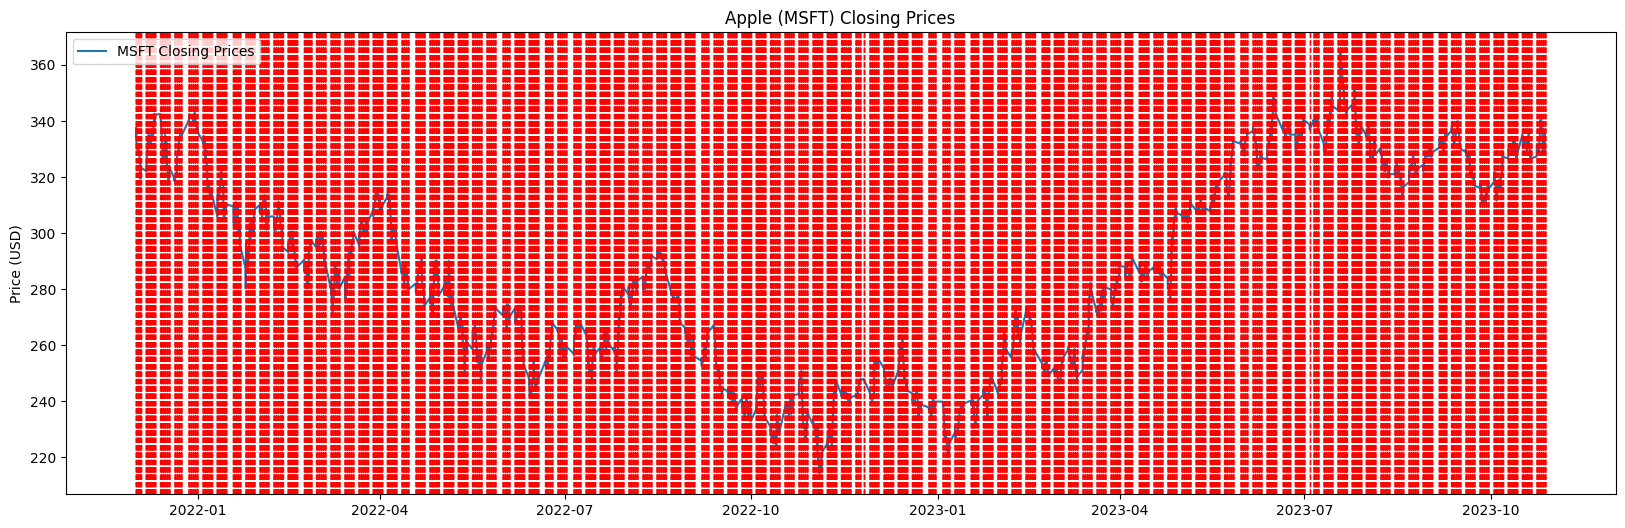

In [74]:
cusum_events = CUSUM_FILTER.getTEvents(df['Close'], h=0.05)
daily_vol = CUSUM_FILTER.getDailyVol(df['Close'], span0=60)

# Assuming 'df' is your DataFrame with the data
closing_prices = df[df['Ticker'] == 'MSFT']['Close']

plt.figure(figsize=(20, 6))

# Convert the index back to DateTimeIndex
closing_prices.index = pd.to_datetime(closing_prices.index)

# Assuming 'cusum_events' is a list of strings representing dates
# Convert 'cusum_events' to DateTimeIndex as well
cusum_events = pd.to_datetime(cusum_events)


plt.plot(closing_prices, label='MSFT Closing Prices')
plt.title('Apple (MSFT) Closing Prices')
for event in cusum_events:
    plt.axvline(x=event, color='red', linestyle='--', linewidth=1)

# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1)) 
# plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(False)
plt.show()



In [75]:
print(daily_vol.index)
print(cusum_events)

# Trim 'cusum_events' to start from the first date available in 'daily_vol'
cusum_events_aligned = cusum_events[cusum_events >= daily_vol.index[0]]

# Then you can proceed with using 'cusum_events_aligned' to index 'daily_vol'
trgt = daily_vol.loc[cusum_events_aligned]


DatetimeIndex(['2021-12-02 15:30:00', '2021-12-02 16:30:00',
               '2021-12-02 17:30:00', '2021-12-02 18:30:00',
               '2021-12-02 19:30:00', '2021-12-02 20:30:00',
               '2021-12-03 14:30:00', '2021-12-03 15:30:00',
               '2021-12-03 16:30:00', '2021-12-03 17:30:00',
               ...
               '2023-10-26 17:30:00', '2023-10-26 18:30:00',
               '2023-10-26 19:30:00', '2023-10-27 13:30:00',
               '2023-10-27 14:30:00', '2023-10-27 15:30:00',
               '2023-10-27 16:30:00', '2023-10-27 17:30:00',
               '2023-10-27 18:30:00', '2023-10-27 19:30:00'],
              dtype='datetime64[ns]', name='Date', length=3344, freq=None)
DatetimeIndex(['2021-12-01 15:30:00', '2021-12-01 16:30:00',
               '2021-12-01 17:30:00', '2021-12-01 18:30:00',
               '2021-12-01 19:30:00', '2021-12-01 20:30:00',
               '2021-12-02 14:30:00', '2021-12-02 16:30:00',
               '2021-12-02 17:30:00', '2021-12-02 1

In [76]:
ptsl = [1, 1]

vertical_barriers = TB_LABELING.add_vertical_barrier(cusum_events, df['Close'], num_days=0.9)

# Apply the Triple Barrier Method to get events with barriers
primary_events = TB_LABELING.get_events(
    close= df['Close'],
    t_events=cusum_events,
    pt_sl=ptsl,
    target=trgt,
    min_ret=0.01,
    num_threads=5,
    vertical_barrier_times=vertical_barriers
)

# Get the bins (labels) for each event
primary_labels = TB_LABELING.get_bins(primary_events, df['Close'])
display(primary_labels) 
print(primary_labels['bin'].value_counts())

# Assuming 'df' is your DataFrame and 'labels' is a Series or DataFrame containing the labels
feature_df = df[['Open', 'Close', 'High', 'Low', 'Volume']]
X = feature_df.loc[primary_labels.index, :]
y = primary_labels['bin']  # 'bin' should be a column with the categorical labels -1, 0, 1

# Filter out the '0' labels for the primary model
X_primary = X[y != 0]
y_primary = y[y != 0]

# Retain the index before scaling
X_primary_index = X_primary.index

# Scaling features
scaler = MinMaxScaler()
X_primary_scaled = scaler.fit_transform(X_primary)

# Splitting dataset for primary model, while keeping the index
X_train_primary, X_test_primary, y_train_primary, y_test_primary = train_test_split(
    X_primary_scaled, y_primary, test_size=0.2, random_state=42
)

# Retain indices for the training and testing sets
train_index = X_primary_index[y_primary.index.isin(y_train_primary.index)]
test_index = X_primary_index[y_primary.index.isin(y_test_primary.index)]

# Convert the scaled arrays back into DataFrames with the original indices
X_train_primary_df = pd.DataFrame(X_train_primary, index=train_index)
X_test_primary_df = pd.DataFrame(X_test_primary, index=test_index)




# Creating the primary model - using SVC with RBF kernel inside a Bagging classifier
rbf_svm = SVC(kernel='rbf', probability=True)
svm_ensemble_primary = BaggingClassifier(base_estimator=rbf_svm, n_estimators=100, random_state=42)
svm_ensemble_primary.fit(X_train_primary, y_train_primary)

# Making predictions on the test set for the primary model
y_pred_primary = svm_ensemble_primary.predict(X_test_primary)

# Calculate metrics for the primary model
precision_primary = precision_score(y_test_primary, y_pred_primary, average='macro')
recall_primary = recall_score(y_test_primary, y_pred_primary, average='macro')
f1_primary = f1_score(y_test_primary, y_pred_primary, average='macro')
accuracy_primary = accuracy_score(y_test_primary, y_pred_primary)
conf_matrix_primary = confusion_matrix(y_test_primary, y_pred_primary)

# Output primary model metrics
print('Primary Model Performance:')
print('Precision (Macro-average):', precision_primary)
print('Recall (Macro-average):', recall_primary)
print('F1 Score (Macro-average):', f1_primary)
print('Accuracy:', accuracy_primary)
print('Confusion Matrix:\n', conf_matrix_primary)



2023-11-07 13:11:31.313969 100.0% apply_pt_sl_on_t1 done after 0.04 minutes. Remaining 0.0 minutes.


,ret,trgt,bin
2021-12-06 15:30:00,0.010683,0.010475,1
2021-12-06 16:30:00,0.033354,0.011447,1
2021-12-06 17:30:00,0.028671,0.012618,1
2021-12-06 18:30:00,0.027162,0.013539,1
2021-12-06 19:30:00,0.025555,0.014304,1
...,...,...,...
2023-10-26 15:30:00,0.016800,0.017197,0
2023-10-26 16:30:00,0.019095,0.018336,1
2023-10-26 17:30:00,0.010612,0.018799,0
2023-10-26 18:30:00,0.019485,0.019404,0


bin
 0    2101
-1     495
 1     485
Name: count, dtype: int64


/home/codespace/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Primary Model Performance:
Precision (Macro-average): 0.6079281183932347
Recall (Macro-average): 0.6088602196396204
F1 Score (Macro-average): 0.5968443252532091
Accuracy: 0.5969387755102041
Confusion Matrix:
 [[60 53]
 [26 57]]


In [77]:
#METAMODEL

# prediction for entire set
y_pred_train = svm_ensemble_primary.predict(X_train_primary_df)
y_pred_test = svm_ensemble_primary.predict(X_test_primary_df)

# Create DataFrames for the predictions with the correct indices
sid_train = pd.DataFrame(y_pred_train, index=X_train_primary_df.index)
side_test = pd.DataFrame(y_pred_test, index=X_test_primary_df.index)

# Concatenate the predictions from the training and testing sets
side = pd.concat([sid_train, side_test])


In [78]:
# Assuming 'side' and 'trgt' are both pandas Series or DataFrames and you want to filter 'trgt' to only have indices that are present in 'side'
aligned_trgt = trgt[trgt.index.isin(side.index)]


In [79]:
# Apply the Triple Barrier Method to get events with barriers
meta_events = TB_LABELING.get_events(
    close= df['Close'],
    t_events=cusum_events,
    pt_sl=ptsl,
    target=aligned_trgt,
    min_ret=0.01,
    num_threads=5,
    vertical_barrier_times=vertical_barriers,
    side = side[0]
)
labels_meta = TB_LABELING.get_bins(meta_events, df['Close'])
labels_meta['bin'].value_counts()


2023-11-07 13:11:38.111183 100.0% apply_pt_sl_on_t1 done after 0.01 minutes. Remaining 0.0 minutes.


bin
0    494
1    486
Name: count, dtype: int64

In [80]:
# Assuming 'X' is the DataFrame with the features used for the primary model
# and 'labels' is the DataFrame obtained from the TB_LABELING.get_bins()

# Select the feature rows for the meta-model based on the 'labels' index
X_meta = X.loc[labels_meta.index, :]

# Scale the features if necessary (assuming 'scaler' is already fitted to the primary training set)
X_meta_scaled = scaler.transform(X_meta)

# Split the scaled features into training and testing sets
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    X_meta_scaled, labels_meta['bin'], test_size=0.2, random_state=42, stratify=labels_meta['bin']
)



svc = SVC(probability=True, kernel='linear', random_state=42)

# Initialize the Bagging ensemble classifier, using SVC as the base estimator
svc_ensemble = BaggingClassifier(base_estimator=svc, n_estimators=100, random_state=42)

# Fit the Bagging classifier on the training data
svc_ensemble.fit(X_train_meta, y_train_meta)

y_pred_meta = svc_ensemble.predict(X_test_meta)


# Calculate metrics for the meta model
precision_meta = precision_score(y_test_meta, y_pred_meta, average='macro')
recall_meta = recall_score(y_test_meta, y_pred_meta, average='macro')
f1_meta = f1_score(y_test_meta, y_pred_meta, average='macro')
accuracy_meta = accuracy_score(y_test_meta, y_pred_meta)
conf_matrix_meta = confusion_matrix(y_test_meta, y_pred_meta)

# Output meta model metrics
print('Meta Model Performance:')
print('Precision (Macro-average):', precision_meta)
print('Recall (Macro-average):', recall_meta)
print('F1 Score (Macro-average):', f1_meta)
print('Accuracy:', accuracy_meta)
print('Confusion Matrix:\n', conf_matrix_meta)


/home/codespace/.local/lib/python3.10/site-packages/sklearn/ensemble/_base.py:156: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


Meta Model Performance:
Precision (Macro-average): 0.5281319054903961
Recall (Macro-average): 0.5172341976465687
F1 Score (Macro-average): 0.4670831887076248
Accuracy: 0.5204081632653061
Confusion Matrix:
 [[82 17]
 [77 20]]


In [81]:
# Calculate metrics for the primary model
precision_primary = precision_score(y_test_primary, y_pred_primary, average='macro')
recall_primary = recall_score(y_test_primary, y_pred_primary, average='macro')
f1_primary = f1_score(y_test_primary, y_pred_primary, average='macro')
accuracy_primary = accuracy_score(y_test_primary, y_pred_primary)
conf_matrix_primary = confusion_matrix(y_test_primary, y_pred_primary)

# Output primary model metrics
print('Primary Model Performance:')
print('Precision (Macro-average):', precision_primary)
print('Recall (Macro-average):', recall_primary)
print('F1 Score (Macro-average):', f1_primary)
print('Accuracy:', accuracy_primary)
print('Confusion Matrix:\n', conf_matrix_primary)


# Calculate metrics for the meta model
precision_meta = precision_score(y_test_meta, y_pred_meta, average='macro')
recall_meta = recall_score(y_test_meta, y_pred_meta, average='macro')
f1_meta = f1_score(y_test_meta, y_pred_meta, average='macro')
accuracy_meta = accuracy_score(y_test_meta, y_pred_meta)
conf_matrix_meta = confusion_matrix(y_test_meta, y_pred_meta)

# Output meta model metrics
print('Meta Model Performance:')
print('Precision (Macro-average):', precision_meta)
print('Recall (Macro-average):', recall_meta)
print('F1 Score (Macro-average):', f1_meta)
print('Accuracy:', accuracy_meta)
print('Confusion Matrix:\n', conf_matrix_meta)

Primary Model Performance:
Precision (Macro-average): 0.6079281183932347
Recall (Macro-average): 0.6088602196396204
F1 Score (Macro-average): 0.5968443252532091
Accuracy: 0.5969387755102041
Confusion Matrix:
 [[60 53]
 [26 57]]
Meta Model Performance:
Precision (Macro-average): 0.5281319054903961
Recall (Macro-average): 0.5172341976465687
F1 Score (Macro-average): 0.4670831887076248
Accuracy: 0.5204081632653061
Confusion Matrix:
 [[82 17]
 [77 20]]
